# Config

In [22]:
import pandas as pd
import openpyxl
import re
import ftfy
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from plotnine import ggplot, aes, geom_col, labs, theme_minimal,  coord_flip
from config import RAW_DATA_DIR, PROCESSED_DATA_DIR, FIGURES_DIR, REPORTS_DIR
from plots import plot_satisfaction_bar, plot_target_correlations, analyze_ppe_usage, usage_summary
pd.set_option('future.no_silent_downcasting', True)

# Read data

In [2]:
file_path = RAW_DATA_DIR / "FCTAES_279691_TOTAL_20251006.xlsx"

datos_df = pd.read_excel(file_path, sheet_name="Datos")
print("Datos",datos_df.shape)

labels_df = pd.read_excel(file_path, sheet_name="Labels")
print("Labels",labels_df.shape)

variables_df = pd.read_excel(file_path, sheet_name="Variables")
print("Variables",variables_df.shape)

# codes_df = pd.read_excel(file_path, sheet_name="Codes")
# print("Codes",codes_df.shape)

Datos (1813, 514)
Labels (1813, 514)
Variables (515, 4)


In [14]:
labels_df["CITY_IT"].value_counts()

CITY_IT
Roma    237
Name: count, dtype: int64

# Data processing

In [113]:
# -------------------------------
# Filter rows: motorcycle / moped users
# -------------------------------

# Work on a copy of the original dataframe
motorcycle_df = datos_df.copy()

# Filter labels and data to motorcycle/moped users (column index 22 == 1)
labels_df = labels_df[labels_df.iloc[:, 22] == 1]
motorcycle_df = motorcycle_df[motorcycle_df.iloc[:, 22] == 1]

# Fix text encoding issues in labels
labels_df = labels_df.map(
    lambda x: ftfy.fix_text(str(x)) if isinstance(x, str) else x
)

print("After filtering motorcycle/moped users:", motorcycle_df.shape)


# -------------------------------
# Select relevant columns
# -------------------------------

# General variables
general_columns = (
    [motorcycle_df.columns[12]] +
    motorcycle_df.columns[15:21].tolist() +
    [motorcycle_df.columns[22]] +
    [motorcycle_df.columns[26]]
)

# Part 2 variables
part2_columns = motorcycle_df.columns[29:127].tolist()

# Part 7 variables
part7_columns = motorcycle_df.columns[448:454].tolist()

print("General columns:", general_columns)
print("Part 2 columns:", part2_columns)
print("Part 7 columns:", part7_columns)

# Keep only the selected columns
motorcycle_df = motorcycle_df[general_columns + part2_columns + part7_columns]

print("After selecting relevant columns:", motorcycle_df.shape)


After filtering motorcycle/moped users: (905, 514)
General columns: ['SURVEY_COUNTRY', 'EDAD', 'EDADR', 'CITY_ES', 'CITY_IT', 'CITY_GB', 'CITY_DK', 'P2#1', 'TRANSPORT_1']
Part 2 columns: ['P3#1', 'P3#2', 'P3#3', 'P3#4', 'P4', 'P5', 'P6#1', 'P6#2', 'P6#96', 'P7_1', 'P7_2', 'P7_3', 'P7_4', 'P7_5', 'P7_6', 'P8#1', 'P8#2', 'P8#3', 'P8#97', 'P9#1', 'P9#2', 'P9#3', 'P9#4', 'P9#5', 'P9#6', 'P9#7', 'P9#8', 'P9#9', 'P9#10', 'P9#11', 'P9#12', 'P9#96', 'P9#96#value', 'P10_1', 'P10_2', 'P10_3', 'P10_4', 'P11_1', 'P11_2', 'P11_3', 'P11_4', 'P12_1', 'P12_2', 'P12_3', 'P12_4', 'P13', 'P14#1', 'P14#2', 'P14#3', 'P14#4', 'P14#5', 'P14#6', 'P14#7', 'P14#8', 'P14#9', 'P14#10', 'P14#11', 'P14#96', 'P14#96#value', 'P15_1', 'P15_2', 'P15_3', 'P15_4', 'P15_5', 'P15_6', 'P15_7', 'P15_8', 'P15_9', 'P15_10', 'P16', 'P17', 'P18#1', 'P18#2', 'P18#3', 'P18#4', 'P18#5', 'P18#6', 'P18#7', 'P18#8', 'P18#9', 'P18#10', 'P18#96', 'P18#96#value', 'P19_1', 'P19_2', 'P19_3', 'P19_4', 'P19_5', 'P19_6', 'P19_7', 'P19_8', 'P1

In [ ]:

# # Select only the columns of interest
# cols_to_profile = ['P2#1','SEXO', 'EDAD', 'P4', 'P5', 'P6#1', 'P6#2','P6#96', 
#                    'P3#1', 'P3#2', 'P3#3', 'P3#4']

# df_subset = labels_df[cols_to_profile]

# #Rename columns
# rename_dict = {
#     'P2#1': 'motorcycle_use',
#     'SEXO': 'gender',
#     'EDAD': 'age',
#     'P4': 'usage_frequency',
#     'P5': 'usage_purpose',
#     'P6#1': 'roads_main',
#     'P6#2': 'roads_rural',
#     'P6#96': 'roads_other',
#     'P3#1': 'motorcycle_driver',
#     'P3#2': 'motorcycle_passenger',
#     'P3#3': 'moped_driver',
#     'P3#4': 'moped_passenger'
# }

# # Rename columns in DataFrame
# df_subset = df_subset.rename(columns=rename_dict)


# Analysis Motocyclists profiles

## Rider & context variables to describe


### City

In [114]:
city_cols = ['CITY_ES', 'CITY_IT', 'CITY_GB', 'CITY_DK', 'CITY_GR']
motocycle_df['City'] = (
    labels_df[city_cols]
    .stack()
    .reset_index(level=1, drop=True)
)
print(motocycle_df[['City']].value_counts())


City      
Barcelona     298
Roma          237
London        188
Athína        165
Copenhagen     17
Name: count, dtype: int64


In [115]:
from plotnine import ggplot, aes, geom_bar, coord_flip, labs, theme_minimal
(
    ggplot(motocycle_df, aes(x='reorder(City, City, len)')) # Orders bars by count
    + geom_bar(fill="steelblue") 
    + coord_flip() # Flips the chart to make city names easier to read
    + labs(
        title="Number of Respondents per City",
        x="City",
        y="Count"
    )
    + theme_minimal()
).save(FIGURES_DIR / "respondents_per_city.png", dpi=300)

c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: C:\Users\LucaLiebscht\Desktop\improva\reports\figures\respondents_per_city.png


### Age group


### Gender

In [31]:
motocycle_df['SEXO'] = labels_df['SEXO']

motocycle_df['SEXO'].value_counts()

SEXO
Male                 565
Female               338
Other                  1
Prefer not to say      1
Name: count, dtype: int64

In [32]:
(ggplot(motocycle_df, aes(x='reorder(SEXO, SEXO, len)')) 
    + geom_bar(fill="steelblue") 
    + coord_flip() 
    + labs(
        title="Number of Respondents by Gender",
        x="Gender",
        y="Count"   
        )
    + theme_minimal()
).save(FIGURES_DIR / "respondents_by_gender.png", dpi=300)

c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: C:\Users\LucaLiebscht\Desktop\improva\reports\figures\respondents_by_gender.png


### Riding frequency


In [84]:
motocycle_df["usage_frequency"] = labels_df["P4"]

motocycle_df["usage_frequency"].value_counts()

usage_frequency
At least once a day      403
At least once a week     391
At least once a month     96
At least once a year      15
Name: count, dtype: int64

In [85]:
# 1. Define the correct chronological order
frequency_order = [
    "At least once a day", 
    "At least once a week", 
    "At least once a month", 
    "At least once a year"
]

# 2. Convert the column to an ordered Categorical type
motocycle_df['usage_frequency'] = pd.Categorical(
    motocycle_df['usage_frequency'], 
    categories=frequency_order, 
    ordered=True
)

# 3. Create the plot
(
    ggplot(motocycle_df, aes(x='usage_frequency'))
    + geom_bar(fill="#2c3e50") # A professional dark slate color
    + labs(
        title="Motorcycle Usage Frequency",
        x="Frequency of Use",
        y="Number of Riders"
    )
    + theme_minimal()
).save(FIGURES_DIR / "motorcycle_usage_frequency.png", dpi=300)

c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: C:\Users\LucaLiebscht\Desktop\improva\reports\figures\motorcycle_usage_frequency.png


### Trip purpose (commuting / leisure / delivery)


In [99]:
motocycle_df["usage_purpose"] = labels_df["P5"]

motocycle_df["usage_purpose"].value_counts()

usage_purpose
Commuting to work               381
Shopping, or running errands    270
For recreation / as a hobby     210
For delivery work                26
Other                            18
Name: count, dtype: int64

In [100]:
# Creating the plot
(
    ggplot(motocycle_df, aes(x='reorder(usage_purpose, usage_purpose, len)'))
    + geom_bar(fill="#2c3e50")
    + coord_flip() # Flip makes long text labels (like "Shopping, or running errands") much easier to read
    + labs(
        title="Primary Purpose of Motorcycle Usage",
        x="Purpose",
        y="Count of Respondents"
    )
    + theme_minimal()
).save(FIGURES_DIR / "motorcycle_usage_purpose.png", dpi=300)

c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: C:\Users\LucaLiebscht\Desktop\improva\reports\figures\motorcycle_usage_purpose.png


### Road context (urban vs non-urban)


In [40]:
motocycle_df["roads_main"] = labels_df["P6#1"]
motocycle_df["roads_rural"] = labels_df["P6#2"]
motocycle_df["roads_other"] = labels_df["P6#96"]

print("Roads - Main:", motocycle_df["roads_main"].value_counts())
print("Roads - Rural:", motocycle_df["roads_rural"].value_counts())
print("Roads - Other:", motocycle_df["roads_other"].value_counts())

Roads - Main: roads_main
1.0    702
0.0    203
Name: count, dtype: int64
Roads - Rural: roads_rural
0.0    665
1.0    240
Name: count, dtype: int64
Roads - Other: roads_other
0.0    531
1.0    374
Name: count, dtype: int64


In [48]:
# 1. Identify your dummy columns
road_columns = ["roads_main", "roads_rural", "roads_other"]

# 2. Reshape to "Long" format
# This creates a 'variable' column with the column name and a 'value' column with 1.0/0.0
roads_long = motocycle_df.melt(value_vars=road_columns, var_name="road_type", value_name="selected")

# 3. Filter for only selected options and apply your mapping
road_labels = {
    "roads_main": "Main Roads",
    "roads_rural": "Rural Roads",
    "roads_other": "Other Roads"
}

roads_plot_data = (
    roads_long[roads_long["selected"] == 1.0]
    .assign(road_label=lambda d: d["road_type"].map(road_labels))
)

# 4. Plot
(
    ggplot(roads_plot_data, aes(x='reorder(road_label, road_label, len)'))
    + geom_bar(fill="#16a085")
    + coord_flip()
    + labs(
        title="Types of Roads Used",
        subtitle="Multi-select question: Respondents could select all that apply",
        x="Type of Road",
        y="Number of Respondents"
    )
    + theme_minimal()
).save(FIGURES_DIR / "motorcycle_usage_roads.png", dpi=300)




c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: C:\Users\LucaLiebscht\Desktop\improva\reports\figures\motorcycle_usage_roads.png


### Type of motorcycle/moped (if available)


In [50]:
motocycle_df["motorcycle_driver"] = labels_df["P3#1"]
motocycle_df["motorcycle_passenger"] = labels_df["P3#2"]
motocycle_df["moped_driver"] = labels_df["P3#3"]
motocycle_df["moped_passenger"] = labels_df["P3#4"]


print("Motorcycle Driver:", motocycle_df["motorcycle_driver"].value_counts())
print("Motorcycle Passenger:", motocycle_df["motorcycle_passenger"].value_counts())
print("Moped Driver:", motocycle_df["moped_driver"].value_counts())
print("Moped Passenger:", motocycle_df["moped_passenger"].value_counts())

Motorcycle Driver: motorcycle_driver
1.0    711
0.0    194
Name: count, dtype: int64
Motorcycle Passenger: motorcycle_passenger
0.0    596
1.0    309
Name: count, dtype: int64
Moped Driver: moped_driver
0.0    659
1.0    246
Name: count, dtype: int64
Moped Passenger: moped_passenger
0.0    793
1.0    112
Name: count, dtype: int64


In [56]:
# 1. Define the columns for the role/vehicle multi-select
role_cols = ["motorcycle_driver", "motorcycle_passenger", "moped_driver", "moped_passenger"]

# 2. Melt the dataframe to "Long" format
roles_long = motocycle_df.melt(value_vars=role_cols, var_name="role_type", value_name="selected")

# 3. Create a clean mapping
role_labels = {
    "motorcycle_driver": "Motorcycle Driver",
    "motorcycle_passenger": "Motorcycle Passenger",
    "moped_driver": "Moped Driver",
    "moped_passenger": "Moped Passenger"
}

# 4. Filter for 'selected' and map labels
roles_plot_data = (
    roles_long[roles_long["selected"] == 1.0]
    .assign(clean_label=lambda d: d["role_type"].map(role_labels))
)

(
    ggplot(roles_plot_data, aes(x="reorder(clean_label, clean_label, len)"))
    + geom_bar(fill="#16a085") # A nice purple to distinguish this set
    + coord_flip()
    + labs(
        title="Respondent Roles and Vehicle Types",
        subtitle="Multi-select: Respondents may act as both drivers and passengers",
        x="Role of driver/passenger",
        y="Number of Respondents"
    )
    + theme_minimal()
).save(FIGURES_DIR / "motorcycle_usage_roles.png", dpi=300)

c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: C:\Users\LucaLiebscht\Desktop\improva\reports\figures\motorcycle_usage_roles.png


## Cross-Tabs with PPE use

In [101]:
motocycle_df["use_jacket"] = labels_df["P13"]
motocycle_df["use_leg_protection"] = labels_df["P17"]

# 1. Define the logical order once
safety_usage_order = ["Always", "Most times", "Sometimes", "Never"]

# 2. Apply it to both columns as an ordered Categorical type
for col in ["use_jacket", "use_leg_protection"]:
    motocycle_df[col] = pd.Categorical(
        motocycle_df[col], 
        categories=safety_usage_order, 
        ordered=True
    )



print("Use Jacket:", motocycle_df["use_jacket"].value_counts())
print("Use Leg Protection:", motocycle_df["use_leg_protection"].value_counts())

Use Jacket: use_jacket
Most times    259
Always        201
Sometimes      84
Never           2
Name: count, dtype: int64
Use Leg Protection: use_leg_protection
Always        128
Most times    108
Sometimes      69
Never           9
Name: count, dtype: int64


### PPE use × city


In [95]:
# Reshaping for a combined view
safety_melted = motocycle_df.melt(
    id_vars=['City'], 
    value_vars=['use_jacket', 'use_leg_protection'],
    var_name='Equipment', 
    value_name='Usage'
)

# Note: Melting preserves the "Categorical" nature, but sometimes 
# it helps to re-assert the order on the new column if it loses its 'ordered' property
safety_melted['Usage'] = pd.Categorical(
    safety_melted['Usage'], 
    categories=safety_usage_order, 
    ordered=True
)

(
    ggplot(safety_melted, aes(x='City', fill='Usage'))
    + geom_bar(position="fill")
    + facet_wrap('~Equipment')
    + scale_fill_brewer(type="div",palette="RdYlGn", direction=-1)
    + labs(y="Proportion", title="Safety Usage by City")
    + theme_minimal()
    + theme(axis_text_x=element_text(rotation=45, hjust=1))
).save(FIGURES_DIR / "safety_usage_by_city_with_nan.png", dpi=300)

c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: C:\Users\LucaLiebscht\Desktop\improva\reports\figures\safety_usage_by_city_with_nan.png


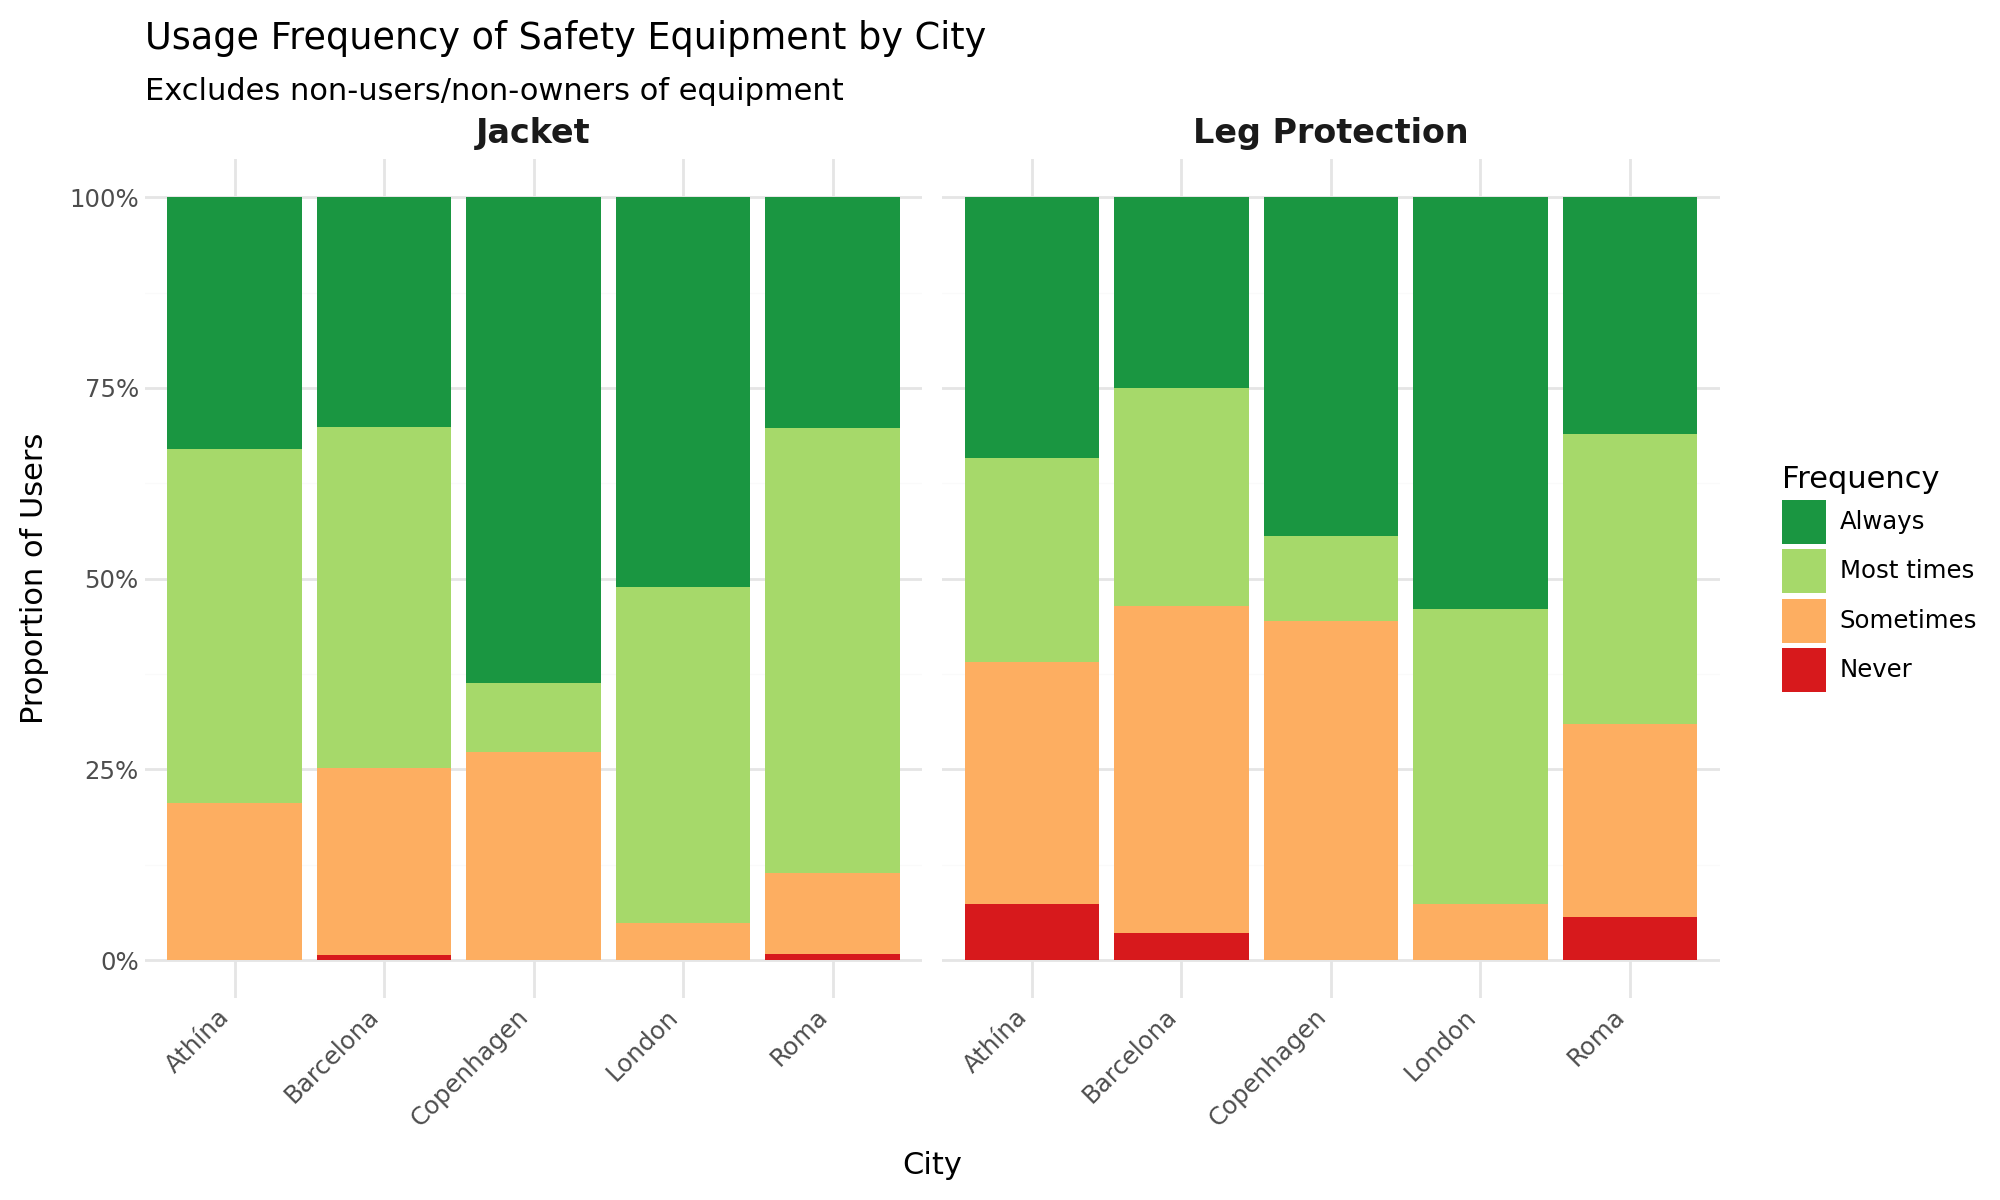

In [ ]:
import pandas as pd
from plotnine import *

# 1. Define the columns and the logical order
ppe_columns = ["use_jacket", "use_leg_protection"]
safety_order = ["Always", "Most times", "Sometimes", "Never"]

# 2. Melt the dataframe and drop NaNs immediately
# This transforms the data so 'use_jacket' and 'use_leg_protection' 
# become rows under a single 'PPE_Type' column.
ppe_df = (
    motocycle_df.melt(
        id_vars=['City'], 
        value_vars=ppe_columns, 
        var_name='PPE_Type', 
        value_name='Usage'
    )
    .dropna(subset=['Usage']) # Removes the people who didn't answer (the NaNs)
)

# 3. Clean the labels for the plot facets
ppe_df['PPE_Type'] = ppe_df['PPE_Type'].map({
    'use_jacket': 'Jacket',
    'use_leg_protection': 'Leg Protection'
})

# 4. Apply the categorical order
ppe_df['Usage'] = pd.Categorical(ppe_df['Usage'], categories=safety_order, ordered=True)

# 5. Create the combined plot
(
    ggplot(ppe_df, aes(x='City', fill='Usage'))
    + geom_bar(position="fill") # 100% stacked bar to normalize city sizes
    + facet_wrap('~PPE_Type')     # Creates the combined side-by-side view
    + scale_y_continuous(labels=lambda l: [f"{int(x*100)}%" for x in l])
    + scale_fill_brewer(type="div", palette="RdYlGn", direction=-1) # Green for Always, Red for Never
    + labs(
        title="Usage Frequency of Safety Equipment by City",
        subtitle="Excludes non-users/non-owners of equipment",
        x=None,
        y="Proportion of Users",
        fill="Frequency"
    )
    + theme_minimal()
    + theme(
        axis_text_x=element_text(rotation=45, hjust=1),
        figure_size=(10, 6),
        strip_text=element_text(size=12, fontweight='bold') # Makes "Jacket" and "Leg Protection" labels pop
    )
).save(FIGURES_DIR / "safety_usage_by_city.png", dpi=300)



### PPE use × riding frequency


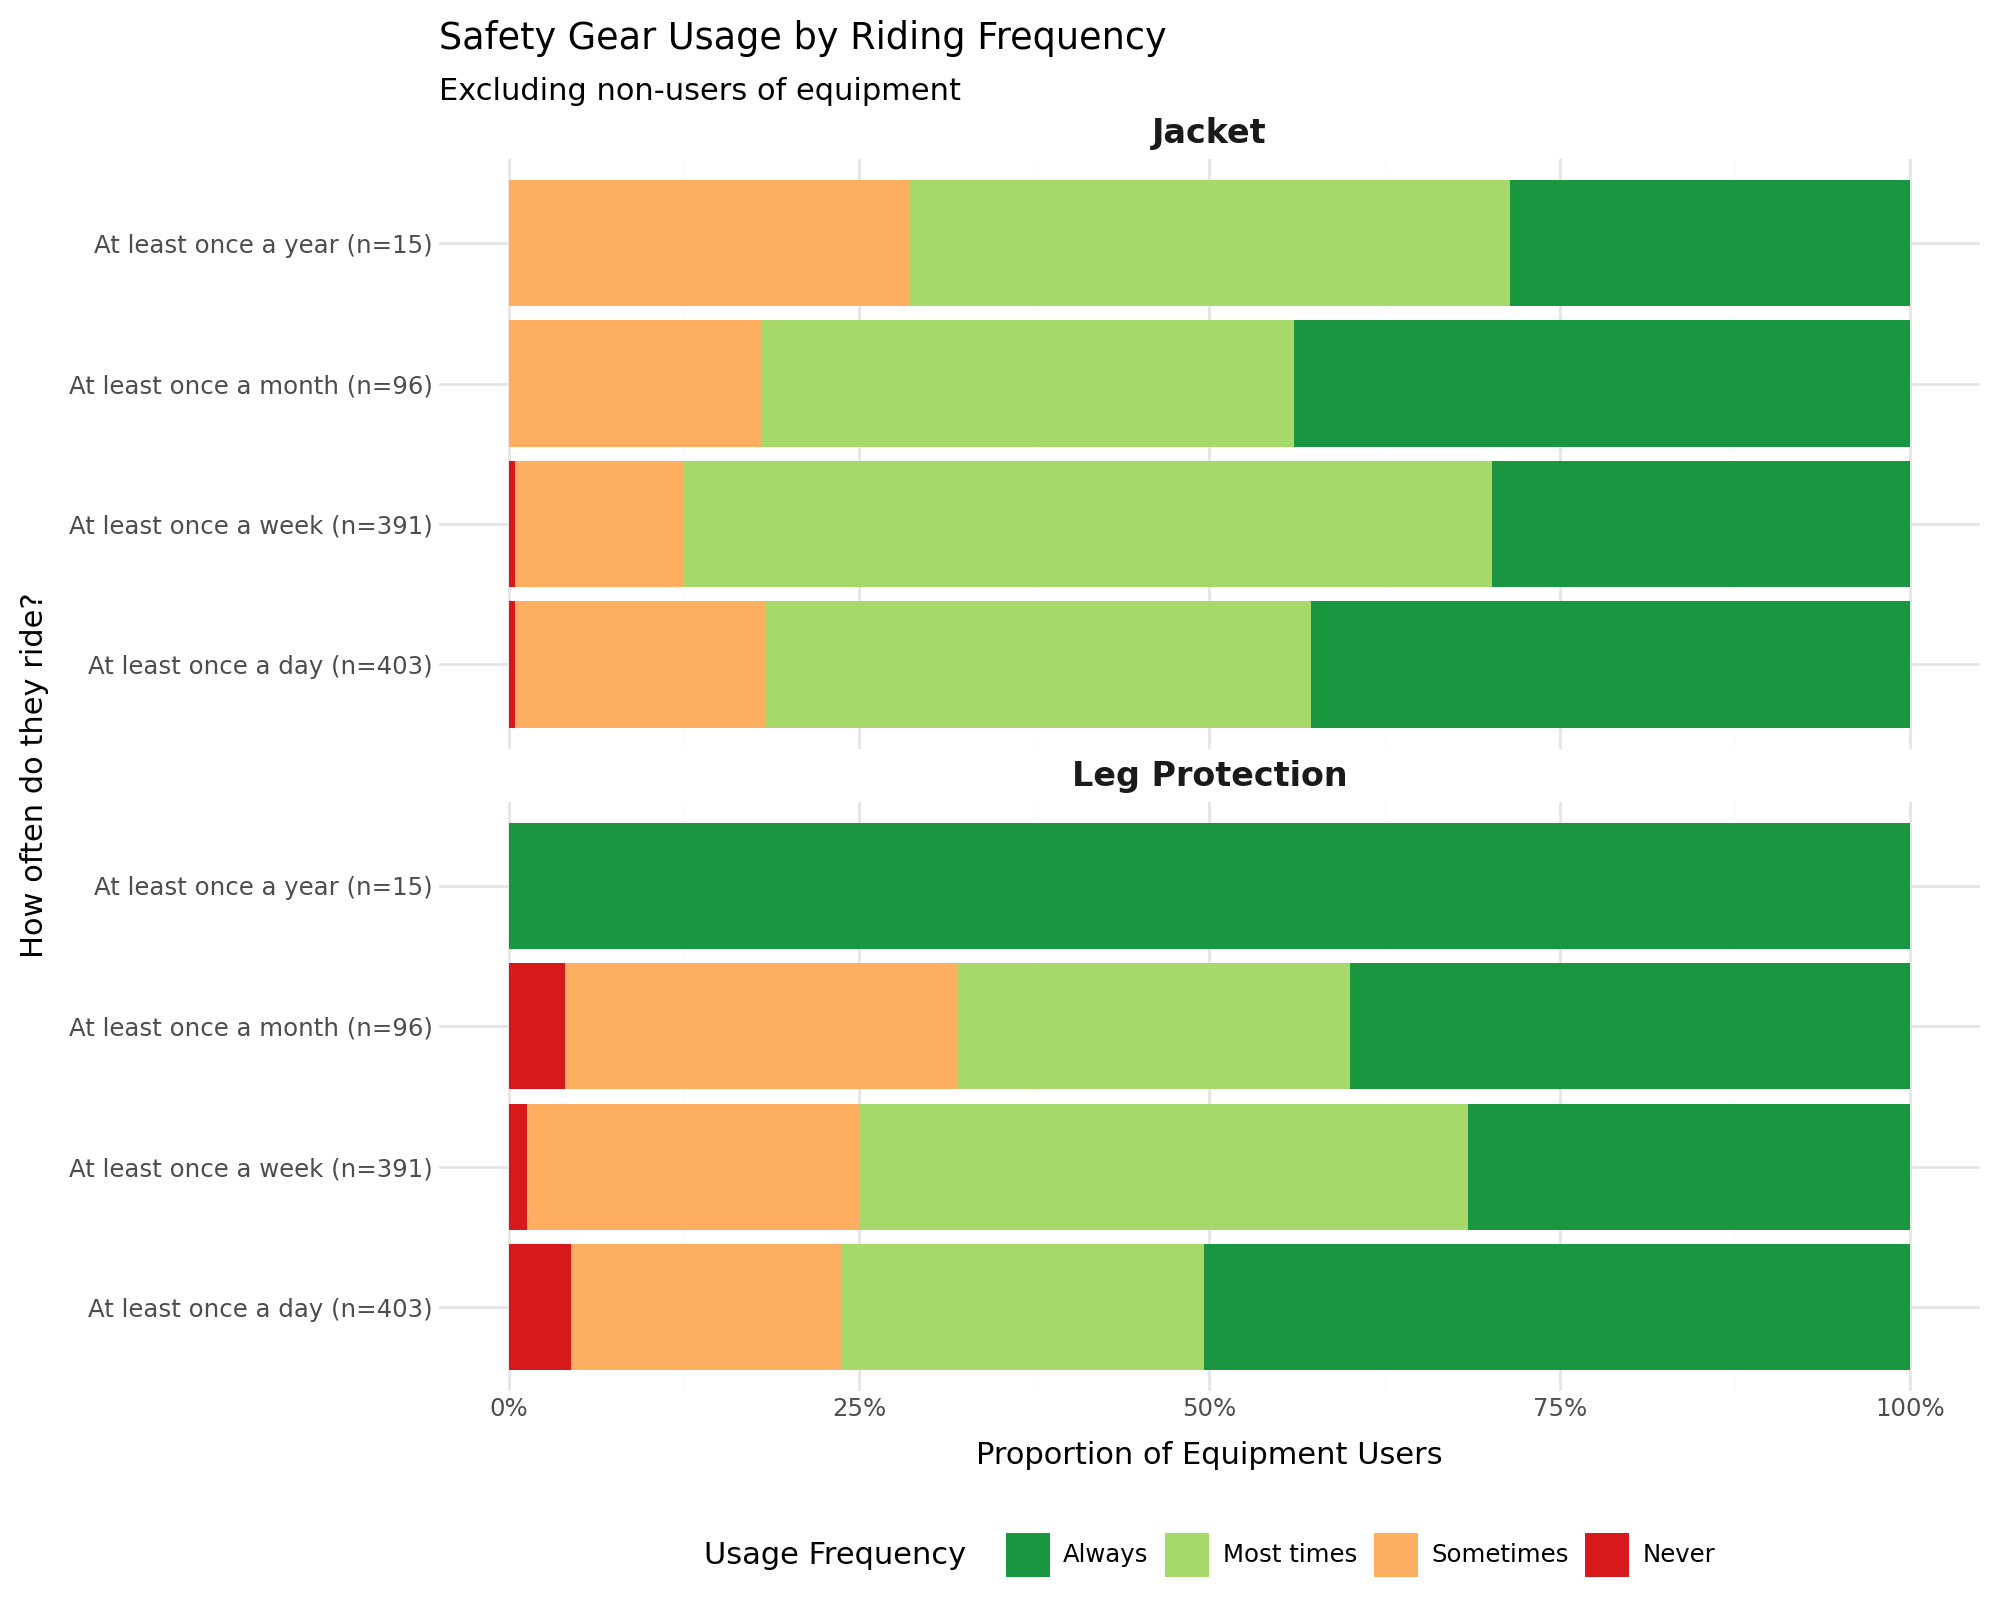

In [93]:
# 1. Define the orders (assuming 'usage_frequency' was set up earlier)
frequency_order = ["At least once a day", "At least once a week", "At least once a month", "At least once a year"]
safety_order = ["Always", "Most times", "Sometimes", "Never"]

# 2. Reshape and Filter
# We keep usage_frequency as our 'base' and melt the PPE columns
ppe_freq_df = (
    motocycle_df.melt(
        id_vars=['usage_frequency'], 
        value_vars=['use_jacket', 'use_leg_protection'],
        var_name='PPE_Type', 
        value_name='Safety_Usage'
    )
    .dropna(subset=['Safety_Usage', 'usage_frequency']) # Remove NaNs from both
)

# 3. Apply Categorical Orders
ppe_freq_df['usage_frequency'] = pd.Categorical(
    ppe_freq_df['usage_frequency'], categories=frequency_order, ordered=True
)
ppe_freq_df['Safety_Usage'] = pd.Categorical(
    ppe_freq_df['Safety_Usage'], categories=safety_order, ordered=True
)

# 4. Clean Facet Labels
ppe_freq_df['PPE_Type'] = ppe_freq_df['PPE_Type'].map({
    'use_jacket': 'Jacket',
    'use_leg_protection': 'Leg Protection'
})
# Function to create custom labels with counts
def get_labels_with_n(df, group_col, val_col):
    counts = df.groupby(group_col)[val_col].count()
    return {val: f"{val} (n={counts[val]})" for val in counts.index}

# Since we have two facets, it's actually clearer to apply the labels 
# to the Y-axis specifically for each subplot's data. 
# However, a simpler way is to pre-calculate a 'general' n for the frequency.
total_n = motocycle_df['usage_frequency'].value_counts()
freq_labels = {f: f"{f} (n={total_n[f]})" for f in total_n.index}
# 5. Plot
plot = (
    ggplot(ppe_freq_df, aes(x='usage_frequency', fill='Safety_Usage'))
    + geom_bar(position="fill")
    + facet_wrap('~PPE_Type', ncol=1) # Stacked vertically to give labels room
    + coord_flip()                   # Horizontal bars are better for long frequency strings
    + scale_x_discrete(labels=freq_labels)
    + scale_y_continuous(labels=lambda l: [f"{int(x*100)}%" for x in l])
    + scale_fill_brewer(type="div", palette="RdYlGn", direction=-1)
    + labs(
        title="Safety Gear Usage by Riding Frequency",
        subtitle="Excluding non-users of equipment",
        x="How often do they ride?",
        y="Proportion of Equipment Users",
        fill="Usage Frequency"
    )
    + theme_minimal()
    + theme(
        figure_size=(10, 8),
        legend_position="bottom",
        strip_text=element_text(size=12, fontweight='bold')
    )
)
plot

### PPE use × trip purpose


In [ ]:
# 1. Extract trip purpose and PPE columns
ppe_purpose_df = (
    motocycle_df.melt(
        id_vars=['usage_purpose'], 
        value_vars=['use_jacket', 'use_leg_protection'],
        var_name='PPE_Type', 
        value_name='Usage'
    )
    .dropna(subset=['Usage', 'usage_purpose'])
)

# 2. Clean PPE labels
ppe_purpose_df['PPE_Type'] = ppe_purpose_df['PPE_Type'].map({
    'use_jacket': 'Jacket',
    'use_leg_protection': 'Leg Protection'
})

# 3. Create crosstab
ppe_purpose_crosstab = pd.crosstab(
    ppe_purpose_df['usage_purpose'], 
    ppe_purpose_df['PPE_Type'],
    margins=True
)

display(ppe_purpose_crosstab.style.format("{:,.0f}").set_caption("PPE Usage by Trip Purpose"))

PPE_Type,Jacket,Leg Protection,All
usage_purpose,,,
Commuting to work,226,103,329
For delivery work,22,15,37
For recreation / as a hobby,135,101,236
Other,10,4,14
"Shopping, or running errands",153,91,244
All,546,314,860


### PPE use × urban riding


## COM-B Variables 

In [116]:
survey_attr_map = {
    # -------------------------------------------------
    # P9 — General safety gear (reasons, multi-select)
    # -------------------------------------------------
    "P9#1": "sg_reason_uncomfortable",
    "P9#2": "sg_reason_inconvenient",
    "P9#3": "sg_reason_dont_know_what_to_buy",
    "P9#4": "sg_reason_used_to_no_gear",
    "P9#5": "sg_reason_looks_bad",
    "P9#6": "sg_reason_experienced",
    "P9#7": "sg_reason_short_distance",
    "P9#8": "sg_reason_city_riding",
    "P9#9": "sg_reason_ride_infrequently",
    "P9#10": "sg_reason_not_protective",
    "P9#11": "sg_reason_others_dont_wear",
    "P9#12": "sg_reason_too_expensive",

    # -------------------------------------------------
    # P14 — Jacket with protection (reasons, multi-select)
    # -------------------------------------------------
    "P14#1": "jkt_reason_uncomfortable",
    "P14#2": "jkt_reason_inconvenient",
    "P14#3": "jkt_reason_too_hot",
    "P14#4": "jkt_reason_forget",
    "P14#5": "jkt_reason_looks_bad",
    "P14#6": "jkt_reason_not_protective",
    "P14#7": "jkt_reason_short_distance",
    "P14#8": "jkt_reason_city_riding",
    "P14#9": "jkt_reason_experienced",
    "P14#10": "jkt_reason_only_poor_visibility",
    "P14#11": "jkt_reason_others_dont_wear",

    # -------------------------------------------------
    # P15 — Jacket with protection (attitudes, Likert)
    # -------------------------------------------------
    "P15_1": "jkt_att_carrying_convenient",
    "P15_2": "jkt_att_wearing_pleasant",
    "P15_3": "jkt_att_reduces_injury_risk",
    "P15_4": "jkt_att_not_needed_short_trips",
    "P15_5": "jkt_att_only_needed_highways",
    "P15_6": "jkt_att_only_for_inexperienced",
    "P15_7": "jkt_att_others_wear",
    "P15_8": "jkt_att_friends_approve",
    "P15_9": "jkt_att_family_approve",
    "P15_10": "jkt_att_not_enforced_by_police",

    # -------------------------------------------------
    # P18 — Leg protection (reasons, multi-select)
    # -------------------------------------------------
    "P18#1": "leg_reason_uncomfortable",
    "P18#2": "leg_reason_inconvenient",
    "P18#3": "leg_reason_too_hot",
    "P18#4": "leg_reason_forget",
    "P18#5": "leg_reason_looks_bad",
    "P18#6": "leg_reason_not_protective",
    "P18#7": "leg_reason_short_distance",
    "P18#8": "leg_reason_city_riding",
    "P18#9": "leg_reason_experienced",
    "P18#10": "leg_reason_others_dont_wear",

    # -------------------------------------------------
    # P19 — Leg protection (attitudes, Likert)
    # -------------------------------------------------
    "P19_1": "leg_att_carrying_convenient",
    "P19_2": "leg_att_wearing_pleasant",
    "P19_3": "leg_att_reduces_injury_risk",
    "P19_4": "leg_att_not_needed_short_trips",
    "P19_5": "leg_att_only_needed_highways",
    "P19_6": "leg_att_only_for_inexperienced",
    "P19_7": "leg_att_others_wear",
    "P19_8": "leg_att_friends_approve",
    "P19_9": "leg_att_family_approve",
    "P19_10": "leg_att_not_enforced_by_police",
}

motocycle_df.rename(columns=survey_attr_map, inplace=True)

### CAPABILITY

#### Reasons

In [105]:
target_non_use = ['P9#1', 'P9#2', 'P9#3', 'P9#4', 'P9#5']
target_jacket = ['P14#1','P14#2','P14#3']
tagrte_jacked_agreement = ['P15#1','P15#2']
target_leg = ['P18#1','P18#2','P18#3']
target_leg_agreement = ['P19#1','P19#2']



In [128]:
# The non users
import pandas as pd
from plotnine import *

# 1. Define the columns and labels
reason_cols = ['sg_reason_uncomfortable', 'sg_reason_inconvenient', 'sg_reason_dont_know_what_to_buy']
reason_labels = {
    'sg_reason_uncomfortable': 'Uncomfortable',
    'sg_reason_inconvenient': 'Inconvenient',
    'sg_reason_dont_know_what_to_buy': "Don't know what to buy"
}

# 2. Reshape: Melt and filter for '1.0' (Reason applies)
reasons_long = (
    motocycle_df.melt(value_vars=reason_cols, var_name='Reason', value_name='Selected')
    .query('Selected == 1.0') # Only keep the "Yes, this is a reason" rows
)
reasons_long['Reason'] = reasons_long['Reason'].map(reason_labels)




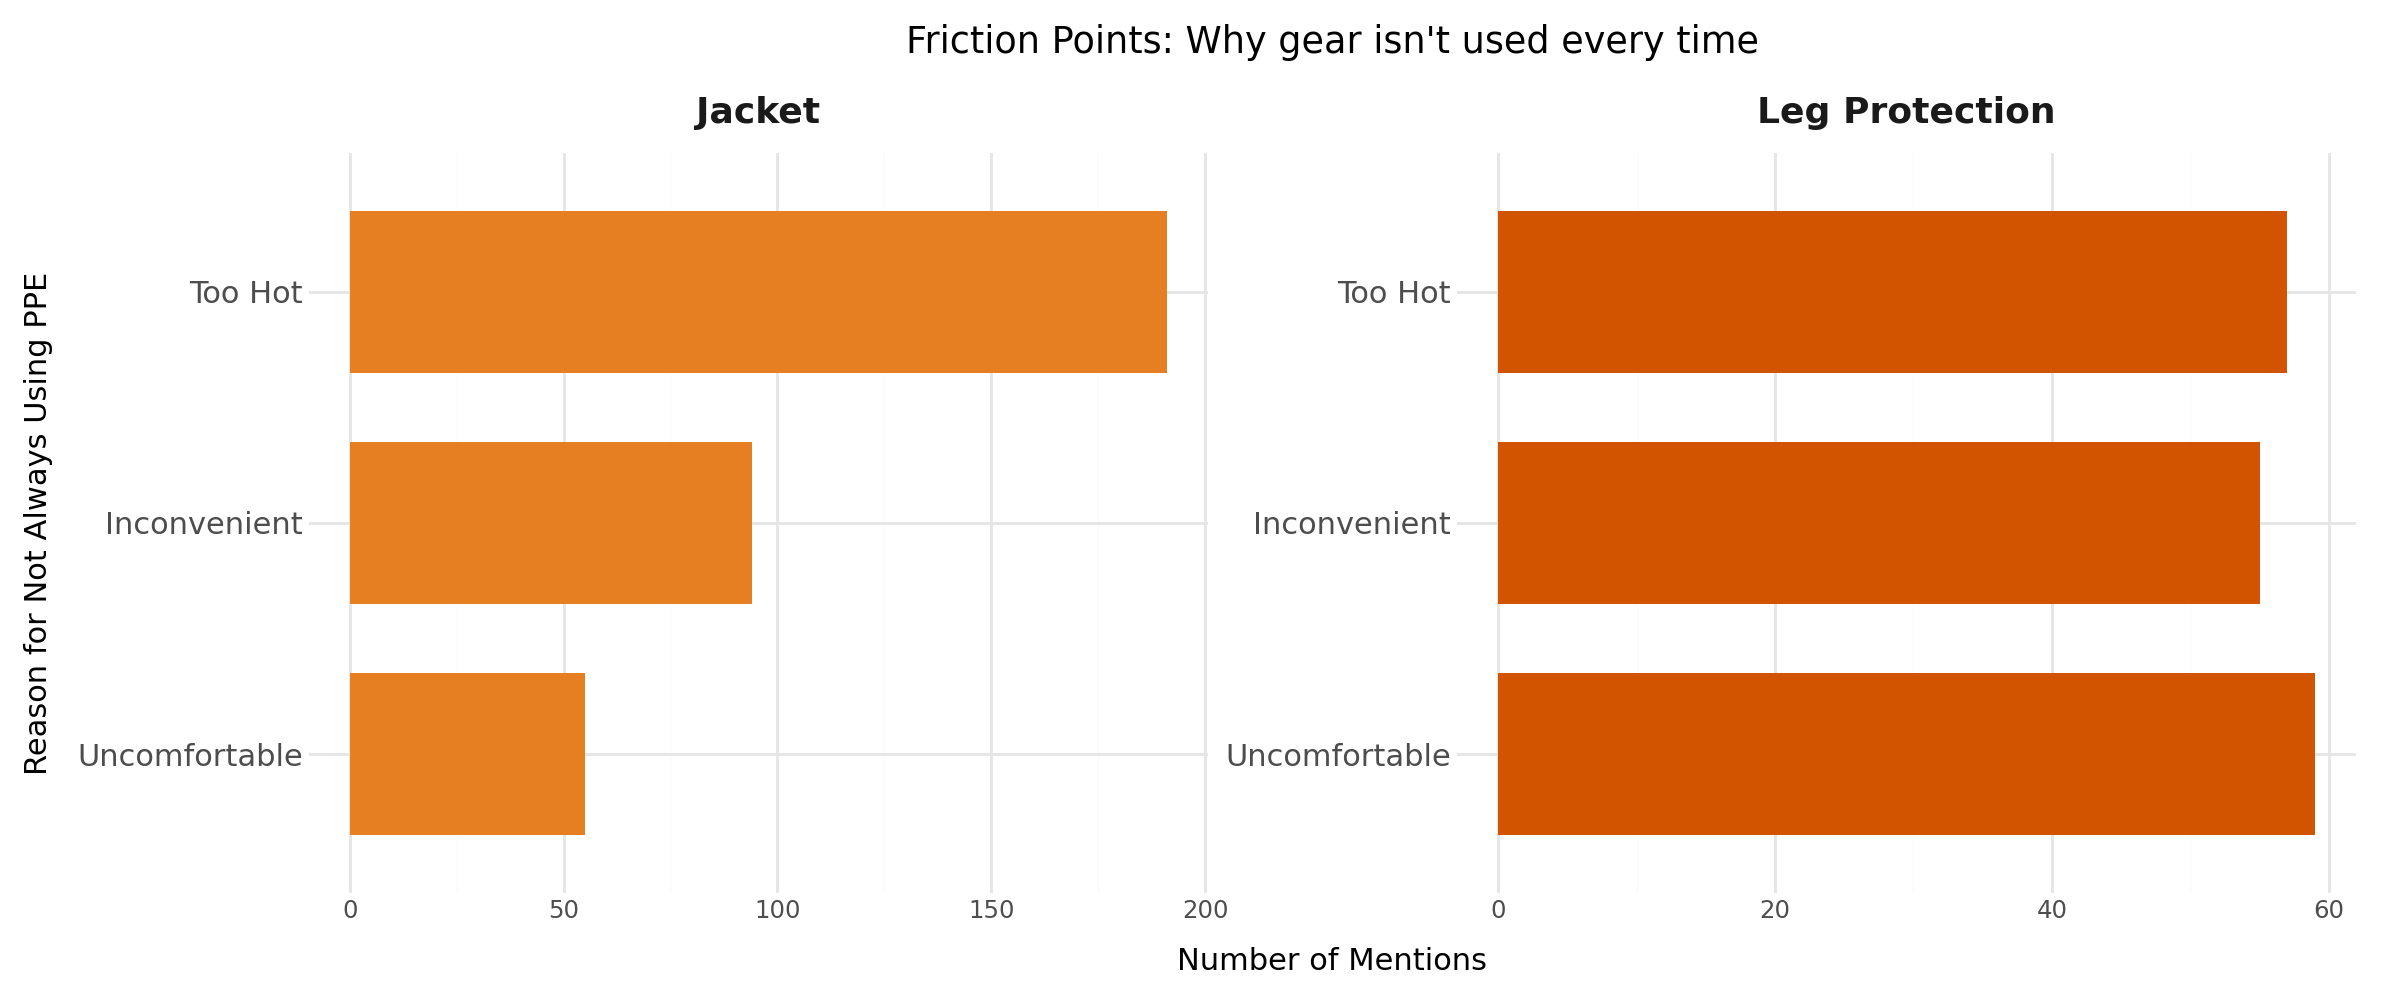

In [149]:
import pandas as pd
from plotnine import *

# 1. Map columns to cleaner labels
barrier_cols = {
    'jkt_reason_uncomfortable': ('Jacket', 'Uncomfortable'),
    'jkt_reason_inconvenient':  ('Jacket', 'Inconvenient'),
    'jkt_reason_too_hot':       ('Jacket', 'Too Hot'),
    'leg_reason_uncomfortable': ('Leg Protection', 'Uncomfortable'),
    'leg_reason_inconvenient':  ('Leg Protection', 'Inconvenient'),
    'leg_reason_too_hot':       ('Leg Protection', 'Too Hot')
}

# 2. Reshape and Filter
barriers_long = (
    motocycle_df.melt(value_vars=barrier_cols.keys(), var_name='original_col', value_name='selected')
    .query('selected == 1.0')
)

# 3. Apply the mapping
barriers_long['Equipment'] = barriers_long['original_col'].apply(lambda x: barrier_cols[x][0])
barriers_long['Reason'] = barriers_long['original_col'].apply(lambda x: barrier_cols[x][1])

plot = (
    ggplot(barriers_long, aes(x="reorder(Reason, Reason, len)", fill="Equipment"))
    + geom_bar(show_legend=False, width=0.7)
    + facet_wrap('~Equipment', ncol=2, scales="free")  # Side by side
    + coord_flip()
    + scale_fill_manual(values={"Jacket": "#E67E22", "Leg Protection": "#D35400"})
    + labs(
        title="Friction Points: Why gear isn't used every time\n",
        x="Reason for Not Always Using PPE",
        y="Number of Mentions"
    )
    + theme_minimal()
    + theme(
        figure_size=(12, 5),  # Wider figure for side-by-side
        strip_text=element_text(size=13, fontweight='bold', margin={'b': 10}),
        axis_text_y=element_text(size=11),
        plot_title=element_text(hjust=0.5),       # Center the title

    )
)


plot

In [131]:
# ==========================================
# 1. Synchronization (Respecting the Hierarchy)
# ==========================================

# We keep the master_order logic exactly as before. 
# It defines the "Ideal" order (e.g., [Hot, Uncomfortable, Inconvenient, Buy])
all_mentions = pd.concat([reasons_long[['Reason']], jacket_reasons[['Reason']], leg_reasons[['Reason']]])
master_order = all_mentions['Reason'].value_counts().index.tolist()

for df in [reasons_long, jacket_reasons, leg_reasons]:
    df['Reason'] = pd.Categorical(df['Reason'], categories=master_order, ordered=True)

# ==========================================
# 2. Plotting (With Automatic Label Filtering)
# ==========================================

# By removing scale_x_discrete(drop=False), plotnine will:
# 1. Look at the master_order.
# 2. Check which of those exist in the CURRENT dataframe.
# 3. Plot only those, but in the master_order sequence.

# --- Plot 1: General Barriers ---
plot_general = (
    ggplot(reasons_long, aes(x="Reason"))
    + geom_bar(fill="#e74c3c") 
    + coord_flip()
    # drop=False removed here: "Too Hot" will vanish if it's not in reasons_long
    + labs(
        title="Barriers to Using Safety Gear",
        subtitle="General non-users (Only showing relevant options)",
        x="Physical & Psychological Barriers",
        y="Number of Mentions"
    )
    + theme_minimal()
)

# --- Plot 2: Jacket Barriers ---
plot_jacket = (
    ggplot(jacket_reasons, aes(x="Reason"))
    + geom_bar(fill="#E67E22", width=0.7)
    + coord_flip()
    + labs(
        title="Barriers to Constant Jacket Use",
        subtitle="Intermittent users",
        x=None,
        y="Number of Mentions"
    )
    + theme_minimal()
    + theme(figure_size=(8, 4))
)

# --- Plot 3: Leg Protection Barriers ---
plot_leg = (
    ggplot(leg_reasons, aes(x="Reason"))
    + geom_bar(fill="#D35400", width=0.7)
    + coord_flip()
    + labs(
        title="Barriers to Constant Leg Protection Use",
        subtitle="Intermittent users",
        x=None,
        y="Number of Mentions"
    )
    + theme_minimal()
    + theme(figure_size=(8, 4))
)

# ==========================================
# 4. Save Outputs
# ==========================================

plot_general.save(FIGURES_DIR / "barriers_general.png", dpi=300)
plot_jacket.save(FIGURES_DIR / "barriers_jacket.png", dpi=300)
plot_leg.save(FIGURES_DIR / "barriers_leg_protection.png", dpi=300)

c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: C:\Users\LucaLiebscht\Desktop\improva\reports\figures\barriers_general.png
c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 8 x 4 in image.
c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: C:\Users\LucaLiebscht\Desktop\improva\reports\figures\barriers_jacket.png
c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 8 x 4 in image.
c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: C:\Users\LucaLiebscht\Desktop\improva\reports\figures\barriers_leg_protection.png


#### Evaluation

In [132]:
import pandas as pd
from plotnine import *

# 1. Map for the Likert scale
likert_map = {
    1: "1 - Disagree",
    2: "2",
    3: "3",
    4: "4",
    5: "5 - Agree"
}
likert_order = ["1 - Disagree", "2", "3", "4", "5 - Agree"]

# 2. Define the columns and their metadata
att_cols = {
    "jkt_att_carrying_convenient": ("Jacket", "Carrying is Convenient"),
    "jkt_att_wearing_pleasant":    ("Jacket", "Wearing is Pleasant"),
    "leg_att_carrying_convenient": ("Leg Protection", "Carrying is Convenient"),
    "leg_att_wearing_pleasant":    ("Leg Protection", "Wearing is Pleasant")
}

# 3. Melt and Transform
att_long = (
    motocycle_df.melt(value_vars=att_cols.keys(), var_name='col', value_name='Score')
    .dropna(subset=['Score'])
)

# Apply mapping and category ordering
att_long['Equipment'] = att_long['col'].apply(lambda x: att_cols[x][0])
att_long['Statement'] = att_long['col'].apply(lambda x: att_cols[x][1])
att_long['Response'] = pd.Categorical(att_long['Score'].map(likert_map), 
                                      categories=likert_order, 
                                      ordered=True)

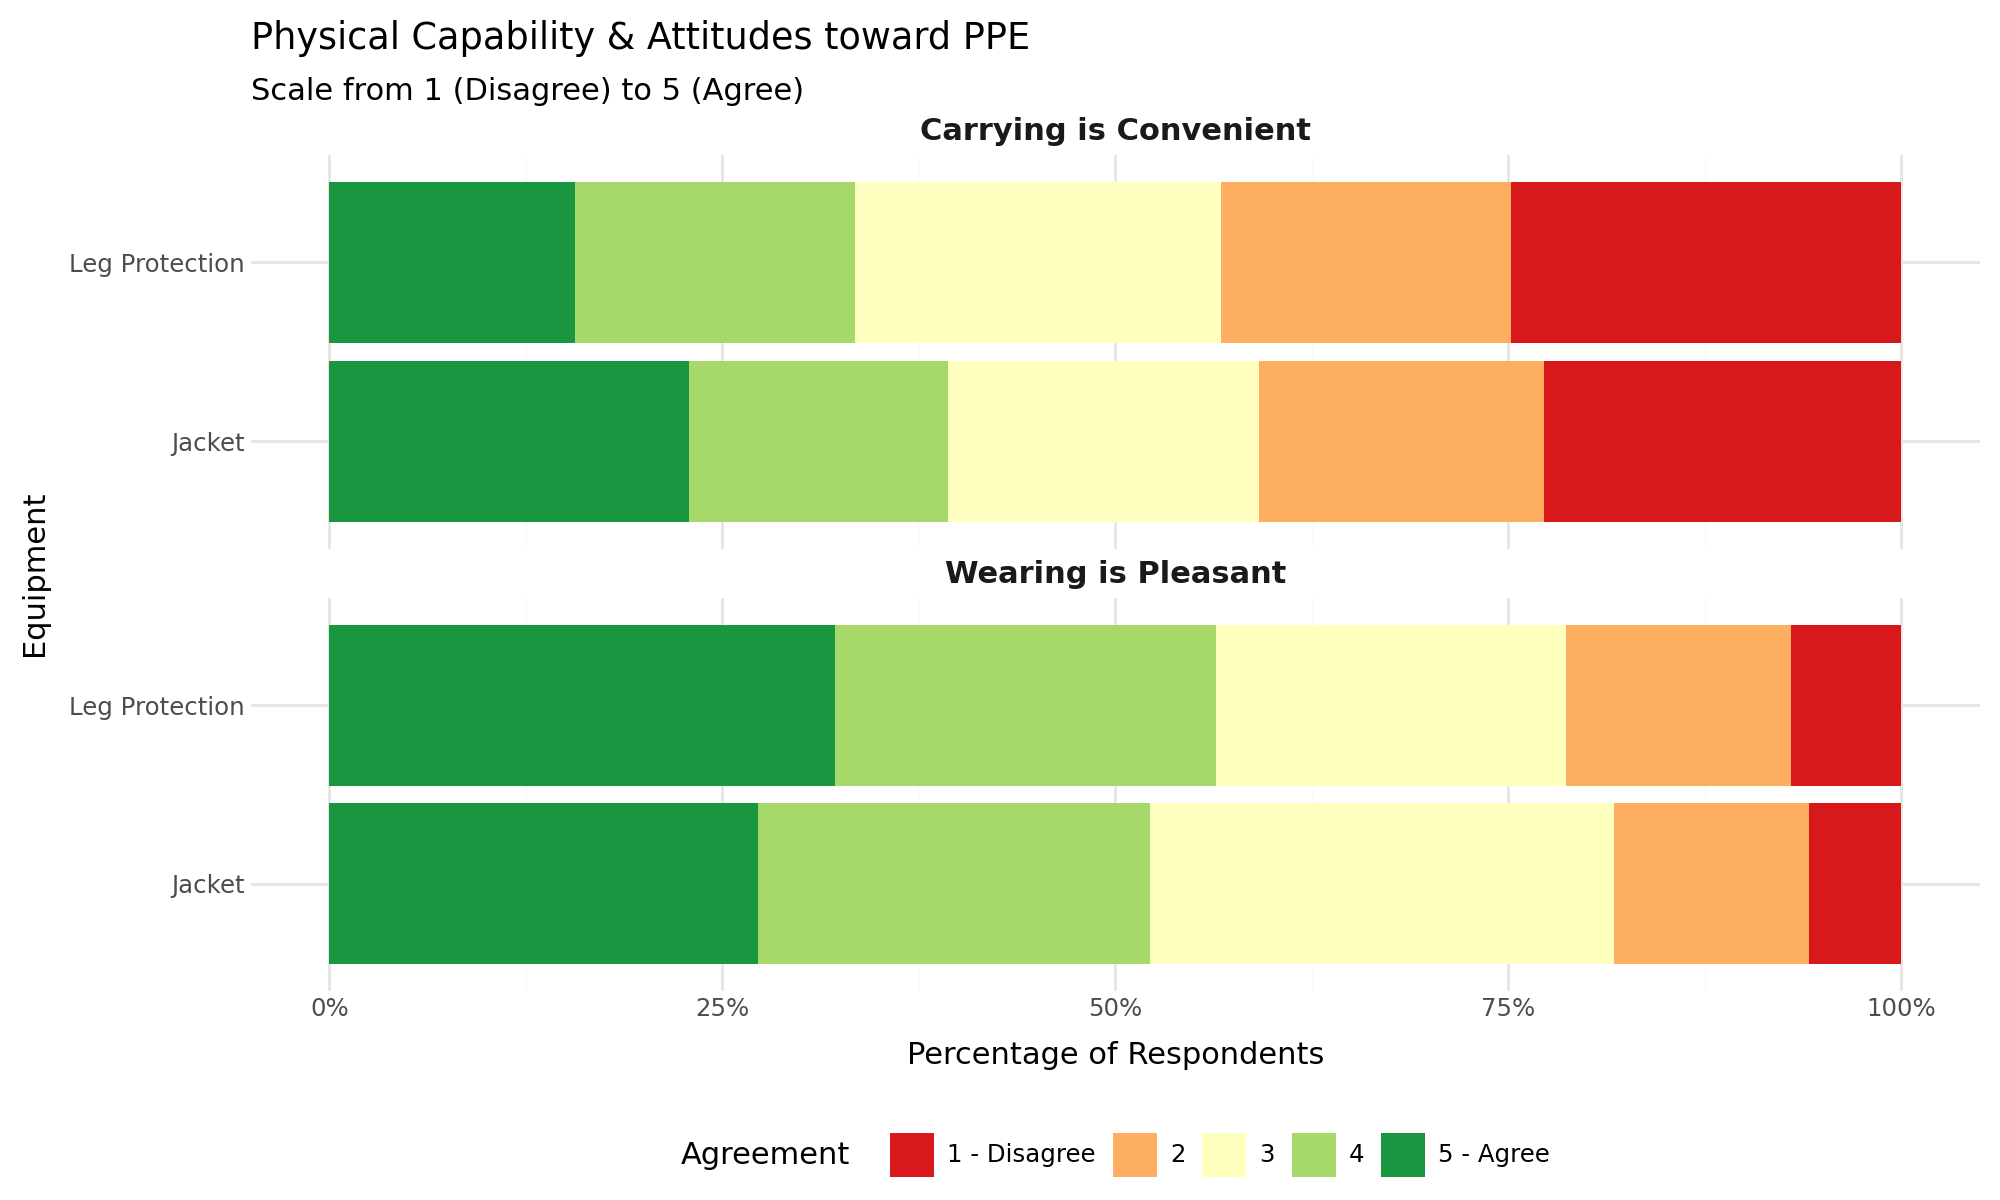

In [139]:
plot_attitudes = (
    ggplot(att_long, aes(x='Equipment', fill='Response'))
    + geom_bar(position="fill")
    + facet_wrap('~Statement', ncol=1) # Stack the two different questions
    + coord_flip()
    + scale_y_continuous(labels=lambda l: [f"{int(x*100)}%" for x in l])
    # Use a diverging color palette (Red to Green)
    + scale_fill_brewer(type="div", palette="RdYlGn")
    + labs(
        title="Physical Capability & Attitudes toward PPE",
        subtitle="Scale from 1 (Disagree) to 5 (Agree)",
        x=None,
        y="Percentage of Respondents",
        fill="Agreement"
    )
    + theme_minimal()
    + theme(
        figure_size=(10, 6),
        legend_position="bottom",
        strip_text=element_text(size=11, fontweight='bold'),
    )
)

plot_attitudes

## Other

### dummy


PPE owners: 546, Ownership rate: 60.33%
Ownership value counts:
P8#2
1.0    546
0.0    359
Name: count, dtype: int64


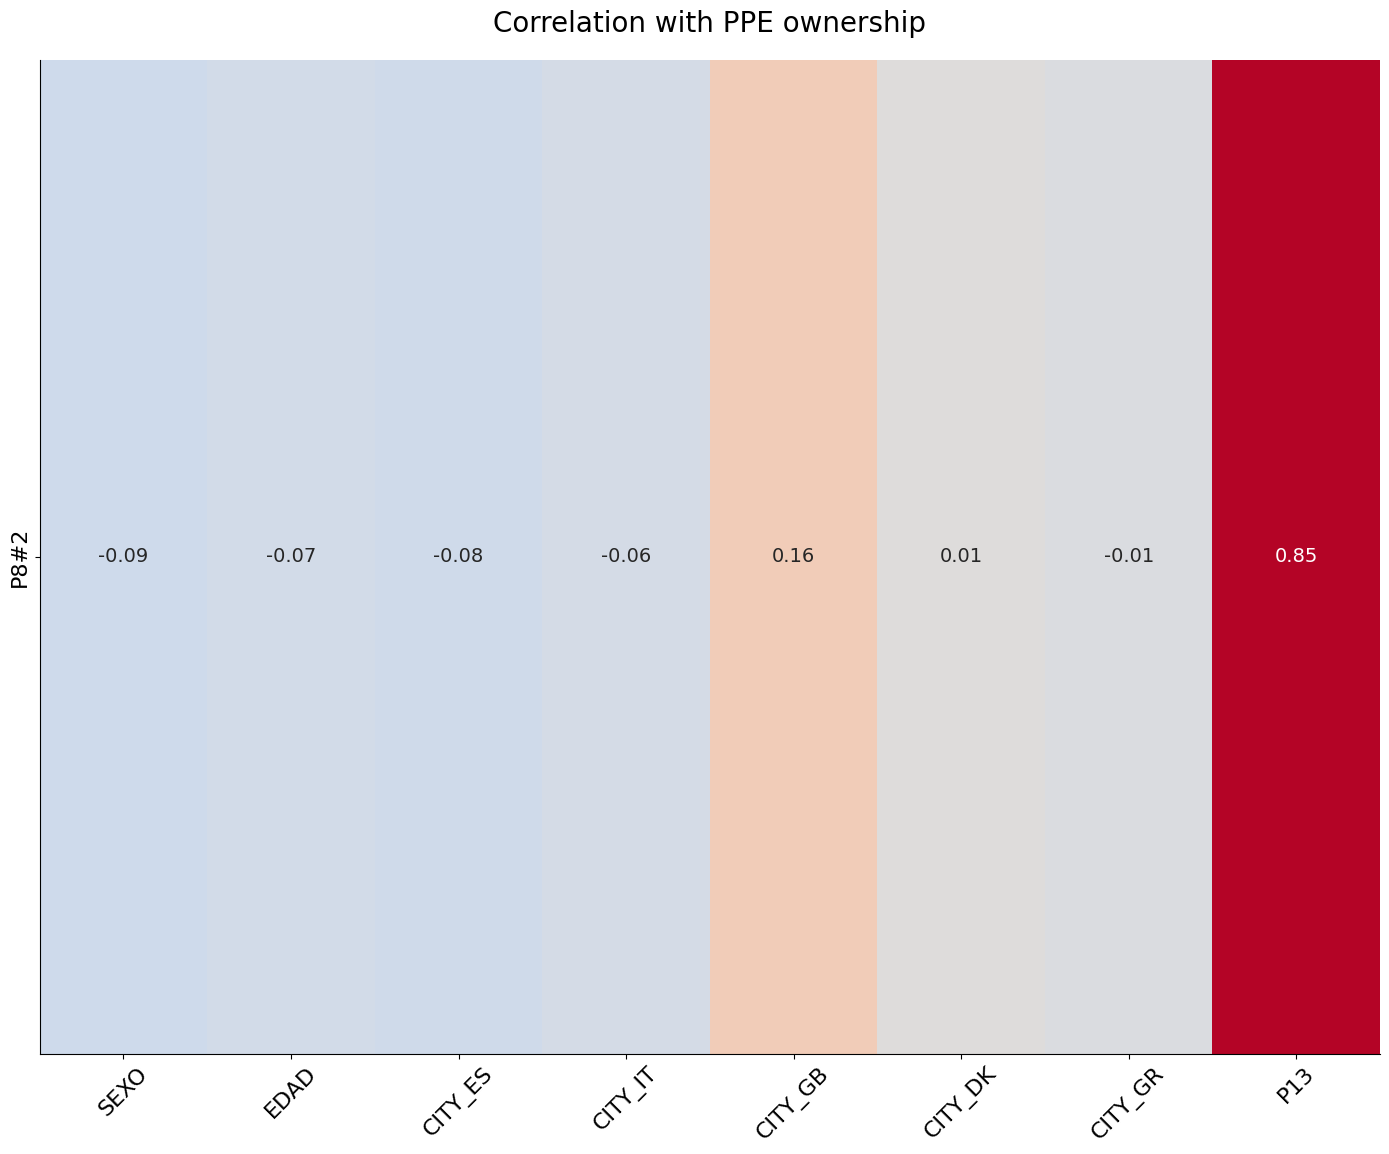

In [11]:
jacket_rellevant_cols = {
    "ownership": 45,
    # "satisfaction": [66, 67, 68, 69],
    "usage": 74,
    # "reasons": [75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86],
    # "reasons_test": 87,
    # "statements": [88,89, 90, 91, 92, 93, 94, 95, 96, 97]
}

jacket_corr, jacket_df = analyze_ppe_usage(
    df=motocycle_df,
    ppe_cols=jacket_rellevant_cols,
    demographics_cols=demographics_col
)


In [ ]:
summary = usage_summary(jacket_df, 74, name="Jacket")

jacket_df.iloc[:, 74].value_counts()

Jacket - Mean: 1.79
Jacket - Median: 2.0
Own but not always using: 343, Percentage: 62.82%
Own but never using: 2, Percentage: 0.37%


P13
2.0    259
1.0    201
3.0     84
4.0      2
Name: count, dtype: int64

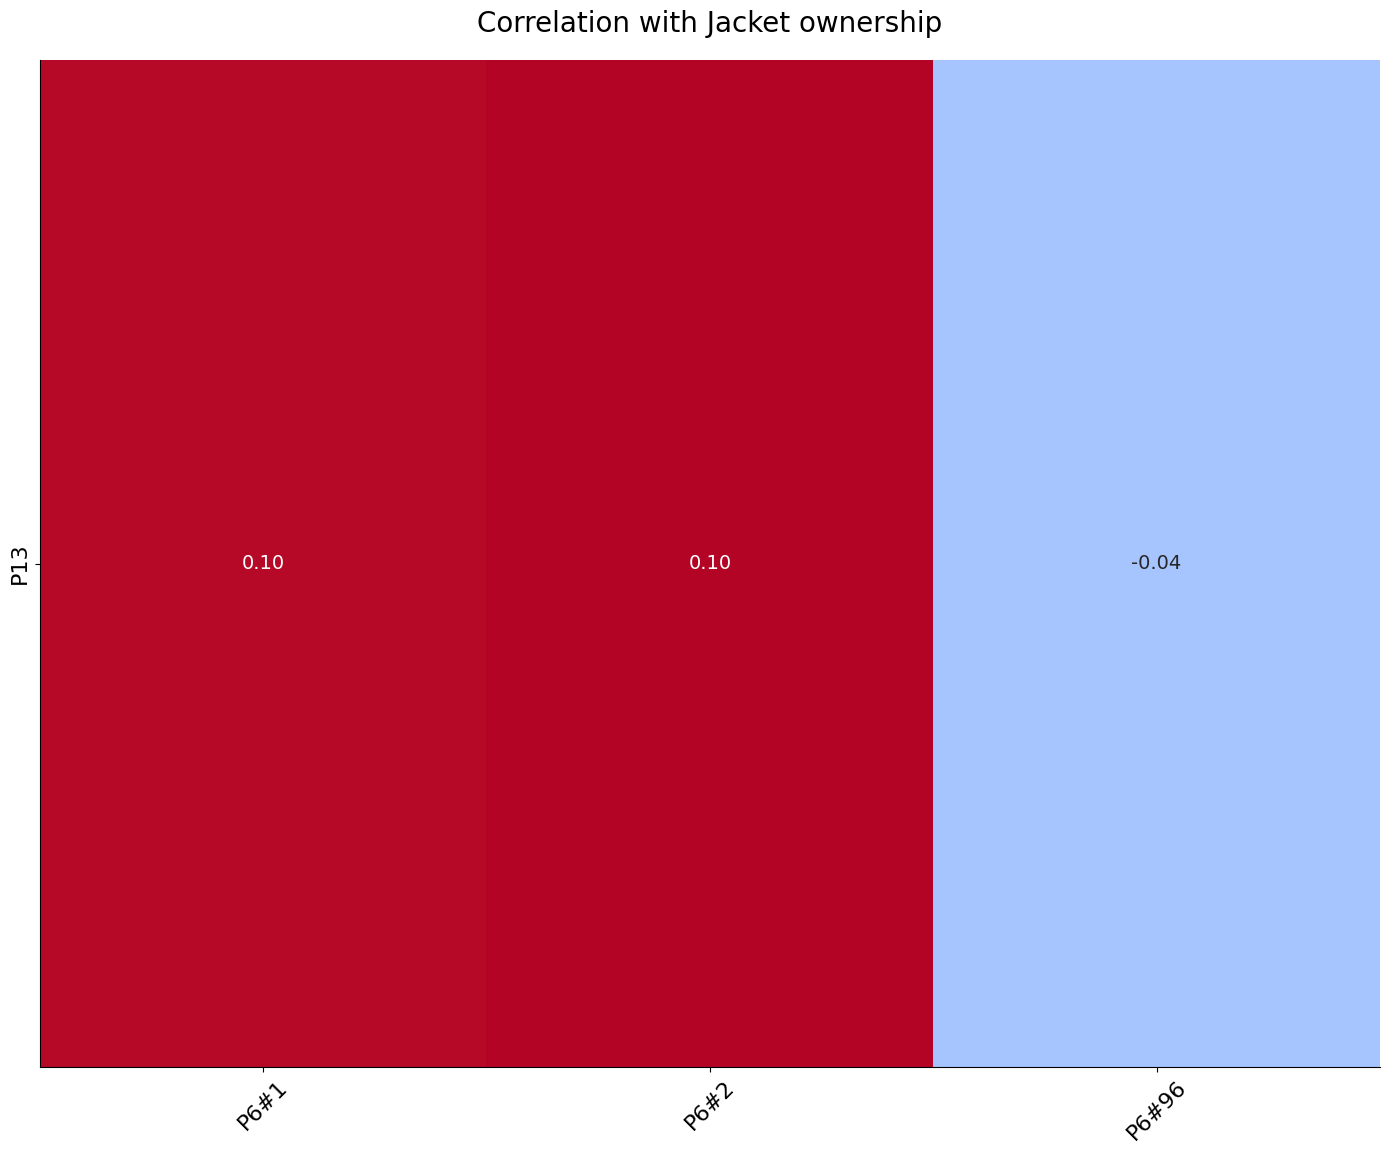

In [79]:
#Type of road
columns = motocycle_df.columns[35:38]

# Example usage
target_col = motocycle_df.columns[74]
jacket_corr =  plot_target_correlations(
    df=motocycle_df,
    target_col=target_col,
    numeric_cols=[target_col] + list(columns),
    label = "Jacket ownership",
)

In [ ]:
cols = jacket_df.columns[66:70]
jacket_satisfaction = plot_satisfaction_bar(
    df=jacket_df,
    cols=cols,
    variables_df=variables_df,
    title = "Satisfaction with Jacket")


# Save data

In [ ]:
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

